# Stage 1: CNN **without** FP_AMPL — LOS / NLOS Classification
## Ablation: Same 1D-CNN Architecture, No FP Late Fusion

**Purpose**: Ablation study — identical CNN encoder to `stage1_cnn_fp.ipynb` but **without FP_AMPL1/2/3** late fusion. This isolates the contribution of FP features vs. pure CIR-driven classification.

| | CNN+FP (original) | CNN No FP (this notebook) | LNN+FP | LNN No FP |
|---|---|---|---|---|
| Input | CIR + FP_AMPL | CIR only (1, 60) | CIR + FP_AMPL | CIR only |
| FP usage | Late fusion (concat) | None | ODE h₀ init | None |
| Classifier input | 144-dim (128+16) | 128-dim (CNN only) | 64-dim | 64-dim |
| Architecture | 1D-CNN + FP proj | 1D-CNN | DualCircuit LTC ODE | DualCircuit LTC ODE |
| Params | ~20.2k | ~19.6k (−FP layers) | ~17.2k | ~16.9k |

**What changes**: `fp_proj` layer removed. Classifier input is 128-dim (CNN GAP output only). No FP_AMPL extraction. Everything else (conv encoder, GAP, classifier structure, training config) is identical.

In [1]:
CONFIG = {
    "pre_crop": 10,
    "post_crop": 50,
    "total_len": 60,
    "search_start": 740,
    "search_end": 890,
    "embedding_size": 128,
    "input_channels": 1,
    "dropout": 0.4,
    "batch_size": 64,
    "max_epochs": 40,
    "lr": 1e-3,
    "weight_decay": 1e-4,
    "warmup_epochs": 3,
    "patience": 10,
    "grad_clip": 1.0,
    "val_ratio": 0.15,
    "test_ratio": 0.15,
    "seed": 42,
}

In [2]:
import copy
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, roc_curve, auc
)
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
torch.manual_seed(CONFIG["seed"])
np.random.seed(CONFIG["seed"])

Device: cuda


---
## Section 2: Data Loading, ROI Alignment & 70/15/15 Split

Identical CIR preprocessing to the CNN+FP — same data, same split, same seed.
**No FP_AMPL features** — CIR only.

**Note**: CNN uses channels-first format `(B, 1, 60)` for Conv1d.

In [3]:
def get_roi_alignment(sig, search_start=CONFIG["search_start"],
                      search_end=CONFIG["search_end"]):
    region = sig[search_start:search_end]
    if len(region) == 0:
        return np.argmax(sig)
    peak_local = np.argmax(region)
    peak_idx = search_start + peak_local
    peak_val = sig[peak_idx]
    noise_section = sig[:search_start]
    if len(noise_section) > 10:
        noise_mean = np.mean(noise_section)
        noise_std = np.std(noise_section)
        threshold = max(noise_mean + 3 * noise_std, 0.05 * peak_val)
    else:
        threshold = 0.05 * peak_val
    leading_edge = peak_idx
    for i in range(peak_idx, max(search_start - 20, 0), -1):
        if sig[i] < threshold:
            leading_edge = i + 1
            break
    return leading_edge


def load_cir_dataset(filepath="../dataset/channels/combined_uwb_dataset.csv"):
    """Returns: X (N, 1, 60) channels-first, y (N,) — no FP features."""
    PRE = CONFIG["pre_crop"]
    TOTAL = CONFIG["total_len"]
    processed_seqs, labels = [], []

    print(f"Loading: {filepath}")
    df = pd.read_csv(filepath)
    cir_cols = sorted(
        [c for c in df.columns if c.startswith('CIR')],
        key=lambda x: int(x.replace('CIR', ''))
    )
    print(f"  Samples: {len(df)}, CIR columns: {len(cir_cols)}")

    for _, row in df.iterrows():
        sig = pd.to_numeric(row[cir_cols], errors='coerce').fillna(0).astype(float).values
        rxpacc_col = 'RXPACC' if 'RXPACC' in row.index else 'RX_PACC'
        rxpacc = float(row.get(rxpacc_col, 128.0))
        if rxpacc > 0:
            sig = sig / rxpacc

        leading_edge = get_roi_alignment(sig)
        start = max(0, leading_edge - PRE)
        end = start + TOTAL
        if end > len(sig):
            end = len(sig)
            start = max(0, end - TOTAL)
        crop = sig[start:end]
        if len(crop) < TOTAL:
            crop = np.pad(crop, (0, TOTAL - len(crop)), mode='constant')
        local_min, local_max = np.min(crop), np.max(crop)
        rng = local_max - local_min
        crop = (crop - local_min) / rng if rng > 0 else np.zeros(TOTAL)

        processed_seqs.append(crop)
        labels.append(float(row['Label']))

    # CNN channels-first: (N, 1, 60)
    X = np.array(processed_seqs).reshape(-1, 1, TOTAL).astype(np.float32)
    y = np.array(labels).astype(np.float32)
    print(f"  Output shape: X={X.shape} (channels-first), y={y.shape}")
    print(f"  LOS: {int(np.sum(y == 0))}, NLOS: {int(np.sum(y == 1))}")
    return X, y


# Load and split 70/15/15 (same seed & stratification as original)
X_all, y_all = load_cir_dataset("../dataset/channels/combined_uwb_dataset.csv")

indices = np.arange(len(y_all))
idx_train, idx_temp = train_test_split(
    indices, test_size=CONFIG["val_ratio"] + CONFIG["test_ratio"],
    stratify=y_all, random_state=CONFIG["seed"]
)
idx_val, idx_test = train_test_split(
    idx_temp, test_size=CONFIG["test_ratio"] / (CONFIG["val_ratio"] + CONFIG["test_ratio"]),
    stratify=y_all[idx_temp], random_state=CONFIG["seed"]
)

X_train, y_train = X_all[idx_train], y_all[idx_train]
X_val,   y_val   = X_all[idx_val],   y_all[idx_val]
X_test,  y_test  = X_all[idx_test],  y_all[idx_test]

print(f"\nSplit (70/15/15):")
print(f"  Train: {X_train.shape[0]} (LOS: {int(np.sum(y_train==0))}, NLOS: {int(np.sum(y_train==1))})")
print(f"  Val:   {X_val.shape[0]} (LOS: {int(np.sum(y_val==0))}, NLOS: {int(np.sum(y_val==1))})")
print(f"  Test:  {X_test.shape[0]} (LOS: {int(np.sum(y_test==0))}, NLOS: {int(np.sum(y_test==1))})")

Loading: ../dataset/channels/combined_uwb_dataset.csv
  Samples: 3600, CIR columns: 1016
  Output shape: X=(3600, 1, 60) (channels-first), y=(3600,)
  LOS: 1800, NLOS: 1800

Split (70/15/15):
  Train: 2520 (LOS: 1260, NLOS: 1260)
  Val:   540 (LOS: 270, NLOS: 270)
  Test:  540 (LOS: 270, NLOS: 270)


---
## Section 3: CNN Model Architecture (No FP Conditioning)

Identical 1D-CNN encoder to the CNN+FP version.
**Differences**: `fp_proj` removed — classifier input is 128-dim (CNN GAP output only).

```
CIR (1, 60) → Conv1d(1→16, k=5) → BN → ReLU
            → Conv1d(16→32, k=5, s=2) → BN → ReLU   [60 → 30]
            → Conv1d(32→128, k=3, s=2) → BN → ReLU  [30 → 15]
            → GAP → 128-dim
                       ↓
              Classifier (128 → 32 → 1)
                       ↓
                    P(NLOS)
```

**No FP late fusion** — classifier sees only CNN-derived CIR features.

In [4]:
class CNN_Classifier(nn.Module):
    """
    1D-CNN WITHOUT FP_AMPL conditioning.

    CIR passes through 3 conv blocks with BatchNorm + GAP to produce a
    128-dim embedding. Classifier operates on CNN features only (128-dim).
    No FP projection — identical conv encoder to CNN+FP.
    """
    def __init__(self, input_channels=1, embedding_size=128, dropout=0.4):
        super().__init__()
        self.embedding_size = embedding_size

        # 1D-CNN encoder (identical to CNN+FP)
        self.encoder = nn.Sequential(
            nn.Conv1d(input_channels, 16, kernel_size=5, padding=2),
            nn.BatchNorm1d(16), nn.ReLU(),
            nn.Conv1d(16, 32, kernel_size=5, padding=2, stride=2),
            nn.BatchNorm1d(32), nn.ReLU(),
            nn.Conv1d(32, embedding_size, kernel_size=3, padding=1, stride=2),
            nn.BatchNorm1d(embedding_size), nn.ReLU(),
        )
        self.gap = nn.AdaptiveAvgPool1d(1)

        # NO fp_proj — classifier sees only CNN features

        # Classifier: embedding_size → 32 → 1
        self.classifier = nn.Sequential(
            nn.Linear(embedding_size, 32),
            nn.SiLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def _encode_cir(self, x):
        """CNN encoder: (B, 1, 60) -> (B, embedding_size)."""
        features = self.encoder(x)
        return self.gap(features).squeeze(-1)

    def forward(self, x, return_dynamics=False):
        cnn_embed = self._encode_cir(x)  # (B, 128)
        pred = self.classifier(cnn_embed)

        if return_dynamics:
            features = self.encoder(x)  # (B, 128, 15)
            return pred, features
        return pred

    def embed(self, x):
        """Return 128-dim CNN embedding for Stage 2/3 compatibility."""
        return self._encode_cir(x)


_m = CNN_Classifier(
    input_channels=CONFIG["input_channels"],
    embedding_size=CONFIG["embedding_size"],
    dropout=CONFIG["dropout"],
)
_total = sum(p.numel() for p in _m.parameters())
print(f"CNN_Classifier parameter count: {_total:,}")
print(f"  Conv encoder:     {sum(p.numel() for p in _m.encoder.parameters()):,}")
print(f"  FP projection:    NONE (no FP conditioning)")
print(f"  Classifier:       {sum(p.numel() for p in _m.classifier.parameters()):,}")
print(f"  Embedding dim:    {_m.embedding_size}")
del _m

CNN_Classifier parameter count: 19,617
  Conv encoder:     15,456
  FP projection:    NONE (no FP conditioning)
  Classifier:       4,161
  Embedding dim:    128


---
## Section 4: Training Pipeline

Same training config as the CNN+FP: AdamW, cosine LR with warmup, early stopping.
**No FP tensors** — model receives only CIR sequences.

In [5]:
def train_model(X_train, y_train, X_val, y_val, config=CONFIG):
    print(f"Training on {len(X_train)} samples, validating on {len(X_val)}")
    print(f"  FP_AMPL conditioning: DISABLED (CIR only)")

    X_tr = torch.tensor(X_train).to(device)
    y_tr = torch.tensor(y_train).unsqueeze(1).to(device)
    X_va = torch.tensor(X_val).to(device)
    y_va = torch.tensor(y_val).unsqueeze(1).to(device)

    train_ds = TensorDataset(X_tr, y_tr)
    train_loader = DataLoader(train_ds, batch_size=config["batch_size"], shuffle=True)

    model = CNN_Classifier(
        input_channels=config["input_channels"],
        embedding_size=config["embedding_size"],
        dropout=config["dropout"],
    ).to(device)

    criterion = nn.BCELoss()
    optimizer = optim.AdamW(model.parameters(), lr=config["lr"],
                            weight_decay=config["weight_decay"])

    warmup_epochs = config["warmup_epochs"]
    total_epochs  = config["max_epochs"]

    def lr_lambda(epoch):
        if epoch < warmup_epochs:
            return (epoch + 1) / warmup_epochs
        progress = (epoch - warmup_epochs) / max(1, total_epochs - warmup_epochs)
        return max(0.01, 0.5 * (1.0 + math.cos(math.pi * progress)))

    scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_lambda)

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "lr": []}
    best_val_acc     = 0
    best_model_state = None
    patience_counter = 0

    for epoch in range(config["max_epochs"]):
        model.train()
        train_loss_sum = 0
        train_correct, train_total = 0, 0

        for batch_x, batch_y in train_loader:
            optimizer.zero_grad()
            pred = model(batch_x)
            loss = criterion(pred, batch_y)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), config["grad_clip"])
            optimizer.step()
            train_loss_sum += loss.item() * len(batch_x)
            train_correct  += ((pred > 0.5).float() == batch_y).sum().item()
            train_total    += len(batch_x)

        train_loss = train_loss_sum / train_total
        train_acc  = train_correct / train_total

        model.eval()
        with torch.no_grad():
            val_pred = model(X_va)
            val_loss = criterion(val_pred, y_va)
            val_acc  = ((val_pred > 0.5).float() == y_va).float().mean().item()

        lr_now = optimizer.param_groups[0]["lr"]
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss.item())
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        history["lr"].append(lr_now)

        scheduler.step()

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1

        if epoch % 5 == 0 or epoch == config["max_epochs"] - 1:
            print(f"  Ep {epoch:>3} | Loss: {train_loss:.4f} | Val Acc: {100*val_acc:.2f}% | Best: {100*best_val_acc:.2f}% | LR: {lr_now:.1e}")

        if patience_counter >= config["patience"]:
            print(f"  Early stopping at epoch {epoch}")
            break

    model.load_state_dict(best_model_state)
    print(f"\nBest Validation Accuracy: {100*best_val_acc:.2f}%")
    return model, (X_va, y_va), history


best_model, best_data, best_history = train_model(X_train, y_train, X_val, y_val)

Training on 2520 samples, validating on 540
  FP_AMPL conditioning: DISABLED (CIR only)
  Ep   0 | Loss: 0.6479 | Val Acc: 77.41% | Best: 77.41% | LR: 3.3e-04
  Ep   5 | Loss: 0.0042 | Val Acc: 100.00% | Best: 100.00% | LR: 9.9e-04
  Ep  10 | Loss: 0.0010 | Val Acc: 100.00% | Best: 100.00% | LR: 9.1e-04
  Early stopping at epoch 14

Best Validation Accuracy: 100.00%


---
## Section 5: Diagnostics

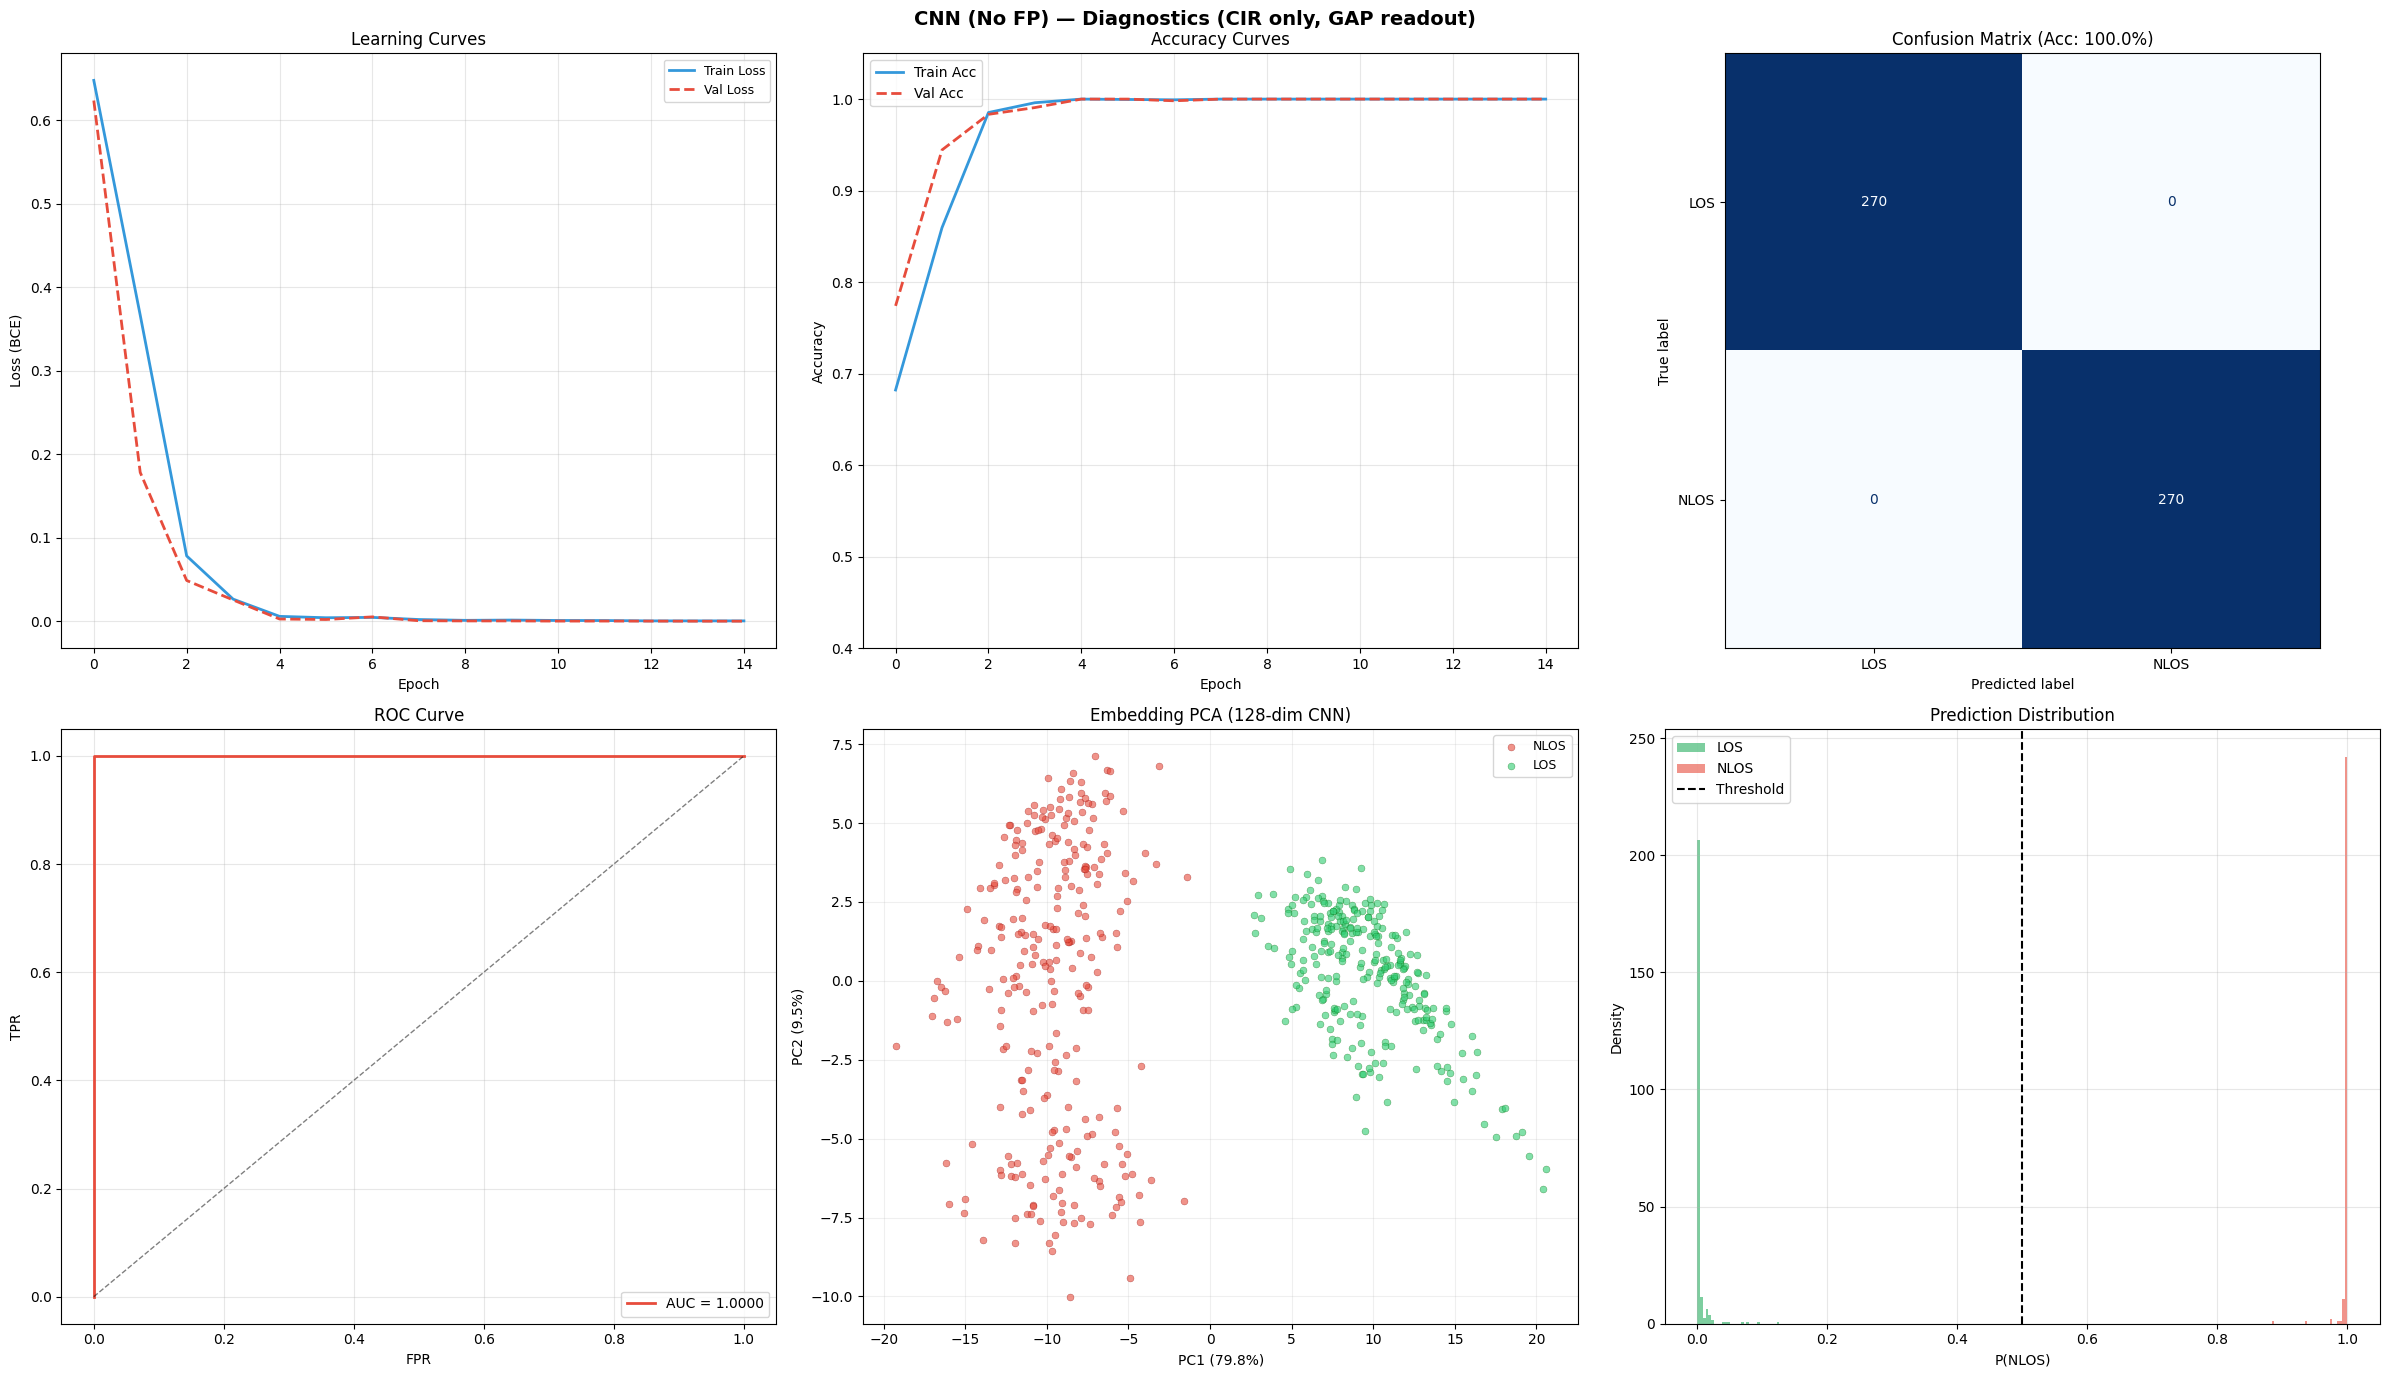

In [6]:
X_va, y_va = best_data

best_model.eval()
with torch.no_grad():
    preds = best_model(X_va)
    embeddings = best_model.embed(X_va).cpu().numpy()

y_true = y_va.cpu().numpy().flatten()
y_prob = preds.cpu().numpy().flatten()
y_pred = (y_prob > 0.5).astype(float)

fig, axs = plt.subplots(2, 3, figsize=(24, 14))
plt.subplots_adjust(hspace=0.35, wspace=0.3)

# --- 1. LEARNING CURVES ---
ax = axs[0, 0]
ax.plot(best_history["train_loss"], label='Train Loss', color='#3498db', lw=2)
ax.plot(best_history["val_loss"],   label='Val Loss',   color='#e74c3c', lw=2, ls='--')
ax.set_title("Learning Curves")
ax.set_xlabel("Epoch"); ax.set_ylabel("Loss (BCE)")
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# --- 2. ACCURACY CURVES ---
ax = axs[0, 1]
ax.plot(best_history["train_acc"], label='Train Acc', color='#3498db', lw=2)
ax.plot(best_history["val_acc"],   label='Val Acc',   color='#e74c3c', lw=2, ls='--')
ax.set_title("Accuracy Curves")
ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy")
ax.set_ylim([0.4, 1.05]); ax.legend(); ax.grid(True, alpha=0.3)

# --- 3. CONFUSION MATRIX ---
ax = axs[0, 2]
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['LOS', 'NLOS'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
acc = (y_true == y_pred).mean()
ax.set_title(f"Confusion Matrix (Acc: {100*acc:.1f}%)")

# --- 4. ROC CURVE ---
ax = axs[1, 0]
fpr, tpr, _ = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)
ax.plot(fpr, tpr, color='#e74c3c', lw=2, label=f'AUC = {roc_auc:.4f}')
ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
ax.set_title("ROC Curve"); ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
ax.legend(loc='lower right'); ax.grid(True, alpha=0.3)

# --- 5. EMBEDDING PCA ---
ax = axs[1, 1]
scaler = StandardScaler()
emb_scaled = scaler.fit_transform(embeddings)
pca = PCA(n_components=2)
emb_pca = pca.fit_transform(emb_scaled)
los_mask = y_true == 0; nlos_mask = y_true == 1
ax.scatter(emb_pca[nlos_mask, 0], emb_pca[nlos_mask, 1],
           c='#e74c3c', s=25, alpha=0.6, edgecolors='darkred', linewidths=0.3, label='NLOS', zorder=4)
ax.scatter(emb_pca[los_mask, 0], emb_pca[los_mask, 1],
           c='#2ecc71', s=25, alpha=0.6, edgecolors='darkgreen', linewidths=0.3, label='LOS', zorder=5)
ax.legend(fontsize=9)
ax.set_title(f"Embedding PCA ({embeddings.shape[1]}-dim CNN)")
ax.set_xlabel(f"PC1 ({100*pca.explained_variance_ratio_[0]:.1f}%)")
ax.set_ylabel(f"PC2 ({100*pca.explained_variance_ratio_[1]:.1f}%)")
ax.grid(True, alpha=0.2)

# --- 6. PREDICTION DISTRIBUTION ---
ax = axs[1, 2]
ax.hist(y_prob[y_true == 0], bins=30, alpha=0.6, color='#27ae60', label='LOS', density=True)
ax.hist(y_prob[y_true == 1], bins=30, alpha=0.6, color='#e74c3c', label='NLOS', density=True)
ax.axvline(0.5, color='black', ls='--', lw=1.5, label='Threshold')
ax.set_title("Prediction Distribution"); ax.set_xlabel("P(NLOS)"); ax.set_ylabel("Density")
ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle('CNN (No FP) \u2014 Diagnostics (CIR only, GAP readout)',
             fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

---
## Section 6: CNN Feature Map Visualization

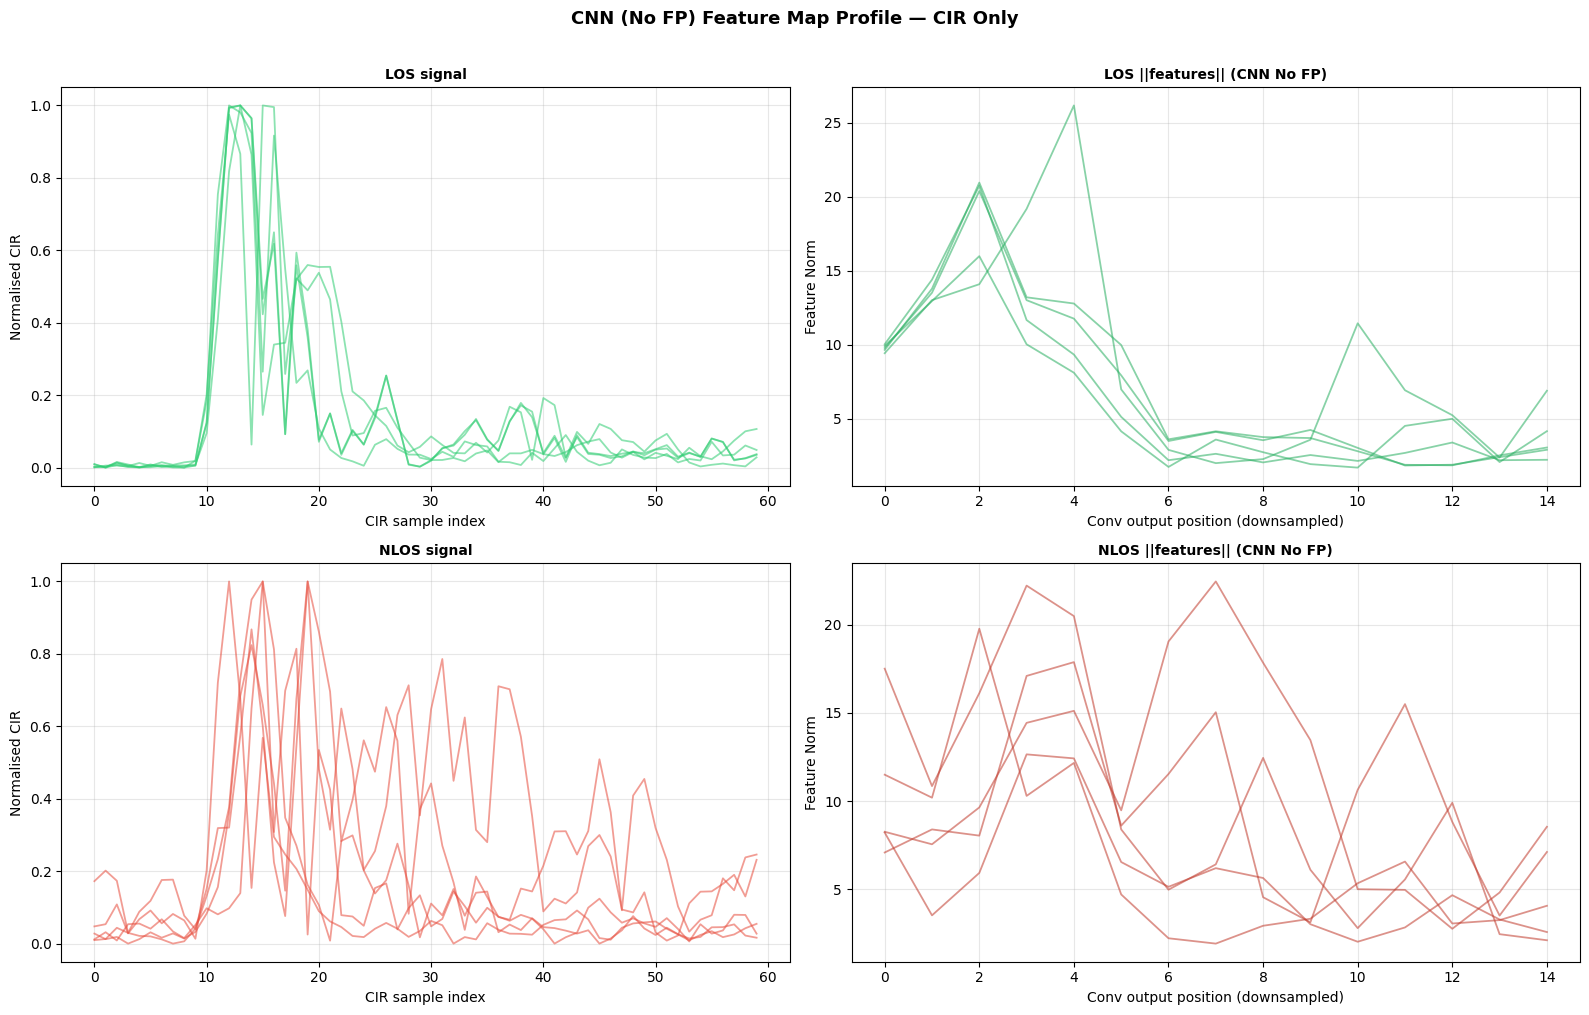

In [7]:
def plot_feature_maps(model, val_data, n_samples=5):
    X_va, y_va = val_data
    model.eval()
    with torch.no_grad():
        _, conv_features = model(X_va, return_dynamics=True)

    y_true = y_va.cpu().numpy().flatten()
    feat_norm = torch.norm(conv_features, dim=1).cpu().numpy()
    x_input = X_va.cpu().numpy().squeeze(1)

    los_idx  = np.where(y_true == 0)[0][:n_samples]
    nlos_idx = np.where(y_true == 1)[0][:n_samples]

    fig, axs = plt.subplots(2, 2, figsize=(16, 10))
    plt.subplots_adjust(hspace=0.4, wspace=0.3)
    titles = [
        ("LOS signal", los_idx, "#2ecc71", x_input),
        ("LOS ||features|| (CNN No FP)", los_idx, "#27ae60", feat_norm),
        ("NLOS signal", nlos_idx, "#e74c3c", x_input),
        ("NLOS ||features|| (CNN No FP)", nlos_idx, "#c0392b", feat_norm),
    ]
    for ax, (title, idx, color, data) in zip(axs.flat, titles):
        for i in idx:
            ax.plot(data[i], alpha=0.55, color=color, lw=1.3)
        ax.set_title(title, fontsize=10, fontweight="bold")
        ax.grid(True, alpha=0.3)
        if "signal" in title:
            ax.set_xlabel("CIR sample index")
            ax.set_ylabel("Normalised CIR")
        else:
            ax.set_xlabel("Conv output position (downsampled)")
            ax.set_ylabel("Feature Norm")
    plt.suptitle("CNN (No FP) Feature Map Profile \u2014 CIR Only",
                 fontsize=13, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()


plot_feature_maps(best_model, best_data, n_samples=5)

---
## Section 7: Test Set Evaluation & Save Artifacts

Test Accuracy: 99.81%
Test AUC:      0.9965

Classification Report:
              precision    recall  f1-score   support

         LOS       1.00      1.00      1.00       270
        NLOS       1.00      1.00      1.00       270

    accuracy                           1.00       540
   macro avg       1.00      1.00      1.00       540
weighted avg       1.00      1.00      1.00       540



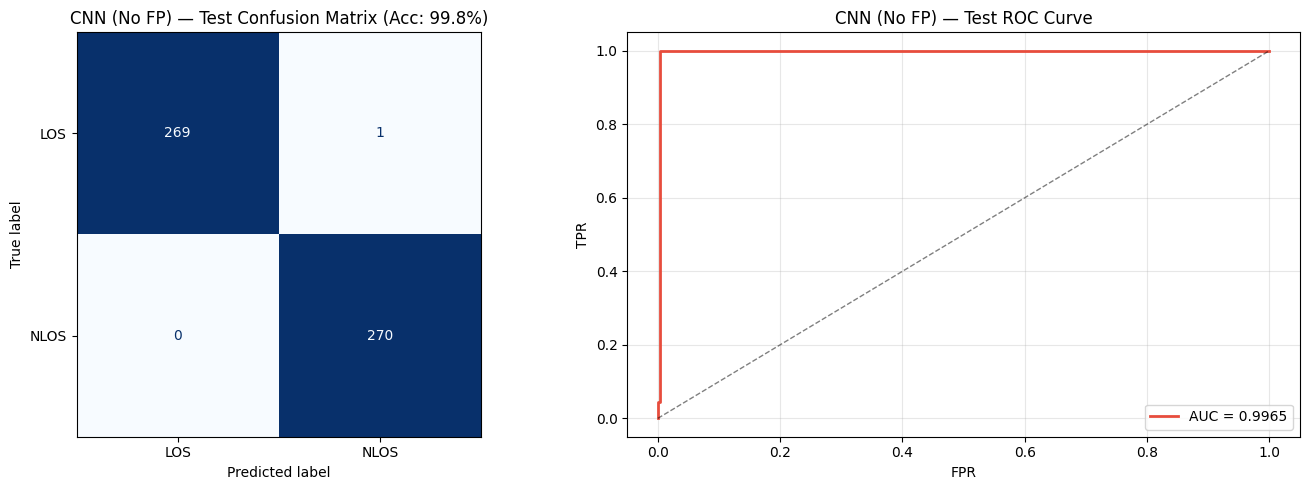


Model summary:
  Architecture: CNN_Classifier (embedding_size=128)
  FP conditioning: NONE (CIR only)
  Embedding dim: 128
  Total params: 19,617


In [8]:
# ── Test Set Evaluation (No FP) ──────────────────────────────────
best_model.eval()
X_te = torch.tensor(X_test).to(device)
y_te = torch.tensor(y_test).unsqueeze(1).to(device)

with torch.no_grad():
    test_pred = best_model(X_te)
    test_prob = test_pred.cpu().numpy().flatten()
    test_acc  = ((test_pred > 0.5).float() == y_te).float().mean().item()
    test_pred_np = (test_prob > 0.5).astype(float)
    test_true_np = y_test.flatten()

fpr, tpr, _ = roc_curve(test_true_np, test_prob)
test_auc = auc(fpr, tpr)

print(f"Test Accuracy: {100*test_acc:.2f}%")
print(f"Test AUC:      {test_auc:.4f}")
print(f"\nClassification Report:")
print(classification_report(test_true_np, test_pred_np, target_names=['LOS', 'NLOS']))

cm = confusion_matrix(test_true_np, test_pred_np)
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

ax = axs[0]
disp = ConfusionMatrixDisplay(cm, display_labels=['LOS', 'NLOS'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f"CNN (No FP) \u2014 Test Confusion Matrix (Acc: {100*test_acc:.1f}%)")

ax = axs[1]
ax.plot(fpr, tpr, color='#e74c3c', lw=2, label=f'AUC = {test_auc:.4f}')
ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
ax.set_title("CNN (No FP) \u2014 Test ROC Curve")
ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
ax.legend(loc='lower right'); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nModel summary:")
print(f"  Architecture: CNN_Classifier (embedding_size={best_model.embedding_size})")
print(f"  FP conditioning: NONE (CIR only)")
print(f"  Embedding dim: {best_model.embedding_size}")
print(f"  Total params: {sum(p.numel() for p in best_model.parameters()):,}")

In [9]:
torch.save(best_model.state_dict(), "stage1_cnn_best.pt")
print("Saved: stage1_cnn_best.pt")

torch.save({
    "config": CONFIG,
    "history": best_history,
}, "stage1_cnn_config.pt")
print("Saved: stage1_cnn_config.pt")

print(f"\nArtifacts ready.")

Saved: stage1_cnn_best.pt
Saved: stage1_cnn_config.pt

Artifacts ready.


---
## Section 8: Summary — FP vs No-FP Comparison

After running both notebooks, compare:

| Metric | CNN+FP | CNN No FP (this) | Difference |
|--------|--------|------------------|------------|
| Val Accuracy | 100% | — | — |
| Test Accuracy | — | — | — |
| Convergence | ~5 epochs | — | — |
| Parameters | ~20.2k | ~19.6k | −FP layers |
| FP_AMPL input | Yes (3 features) | No | Ablated |

**Interpretation**:
- If No-FP matches the original → FP_AMPL doesn't help (CIR alone is sufficient)
- If No-FP is worse → FP_AMPL provides discriminative information for CNN
- Key to watch: convergence speed and final accuracy

In [10]:
print("Stage 1 CNN (No FP) ablation complete.")
print("Model artifact: stage1_cnn_best.pt")
print("Config artifact: stage1_cnn_config.pt")
print("\nCompare with:")
print("  CNN + FP:     capstone/cnn/stage1_cnn_fp.ipynb")
print("  PI-HLNN + FP: capstone/lnn/stage1_pi_hlnn.ipynb")
print("  PI-HLNN No FP: capstone/lnn/stage1_pi_hlnn_no_fp.ipynb")

Stage 1 CNN (No FP) ablation complete.
Model artifact: stage1_cnn_best.pt
Config artifact: stage1_cnn_config.pt

Compare with:
  CNN + FP:     capstone/cnn/stage1_cnn_fp.ipynb
  PI-HLNN + FP: capstone/lnn/stage1_pi_hlnn.ipynb
  PI-HLNN No FP: capstone/lnn/stage1_pi_hlnn_no_fp.ipynb
